In [1]:
from datetime import datetime
from datetime import timedelta
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

from wrf import getvar, interplevel, to_np, get_basemap, latlon_coords
import numpy as np

In [2]:
ncfile = Dataset("/home/fmg-wrf/Build_WRF/WRF_Run/run_WRF/Data/2020-05-18_18/wrfout_d01_2020-05-18_18:00:00")
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from matplotlib._png import read_png

/home/fmg-wrf/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:40: MatplotlibDeprecationWarning: 
The dedent function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use inspect.cleandoc instead.
/home/fmg-wrf/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:41: MatplotlibDeprecationWarning: 
The dedent function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use inspect.cleandoc instead.


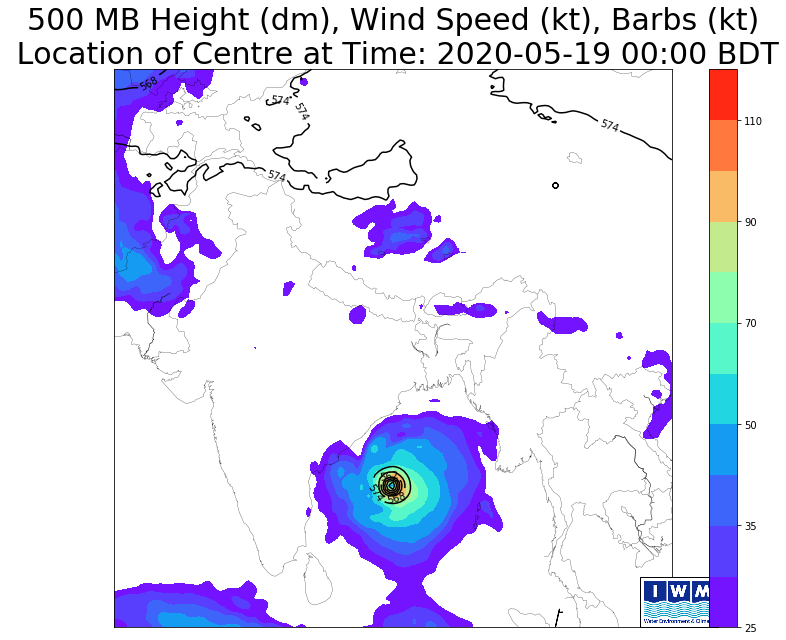

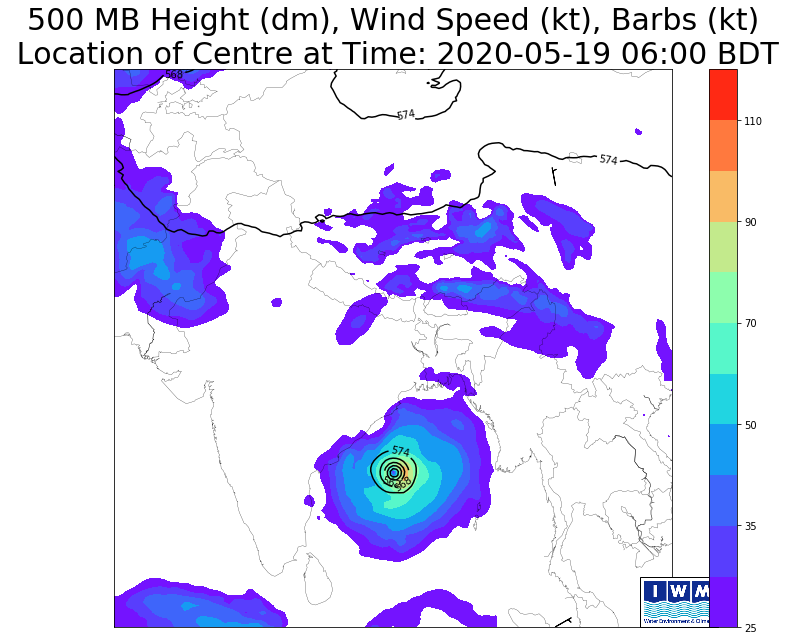

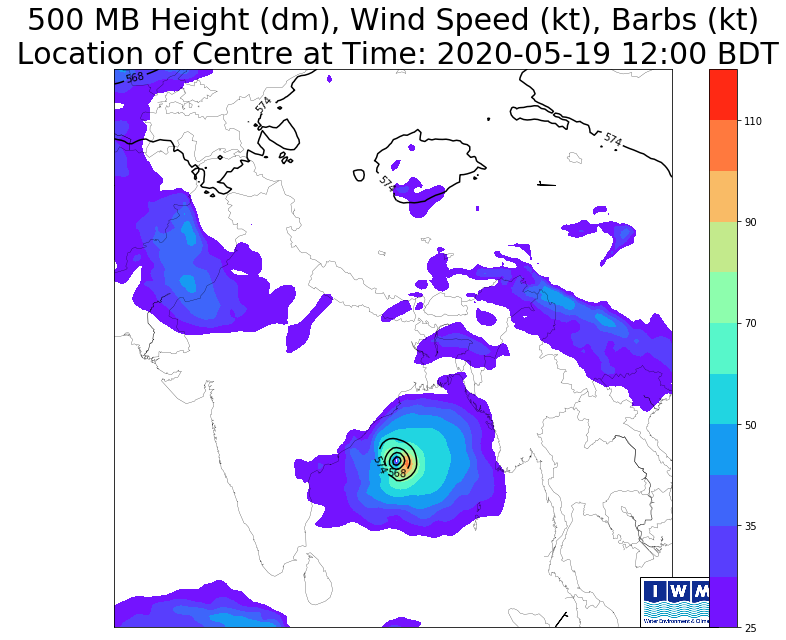

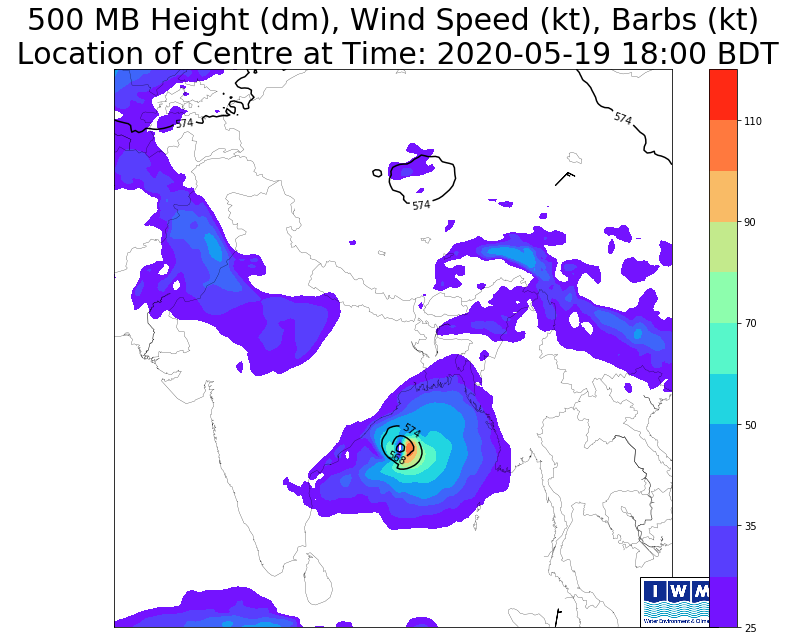

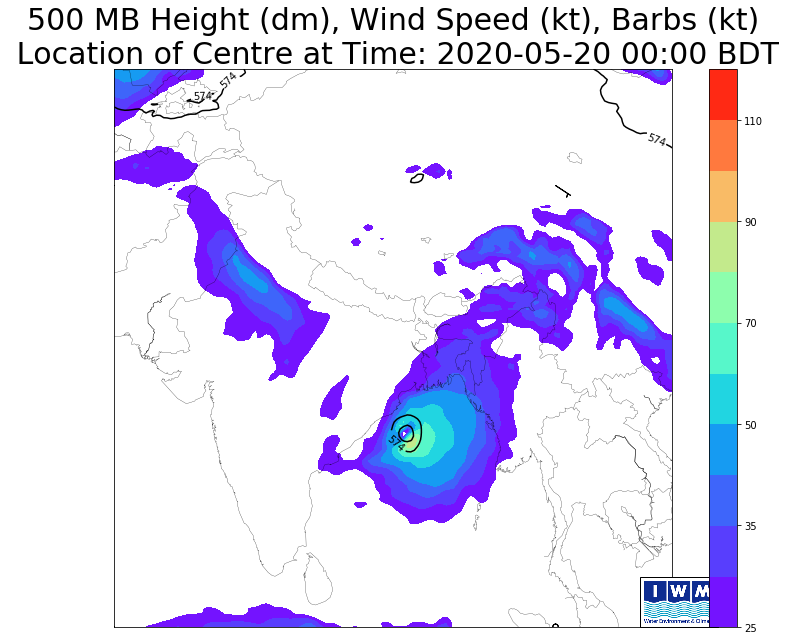

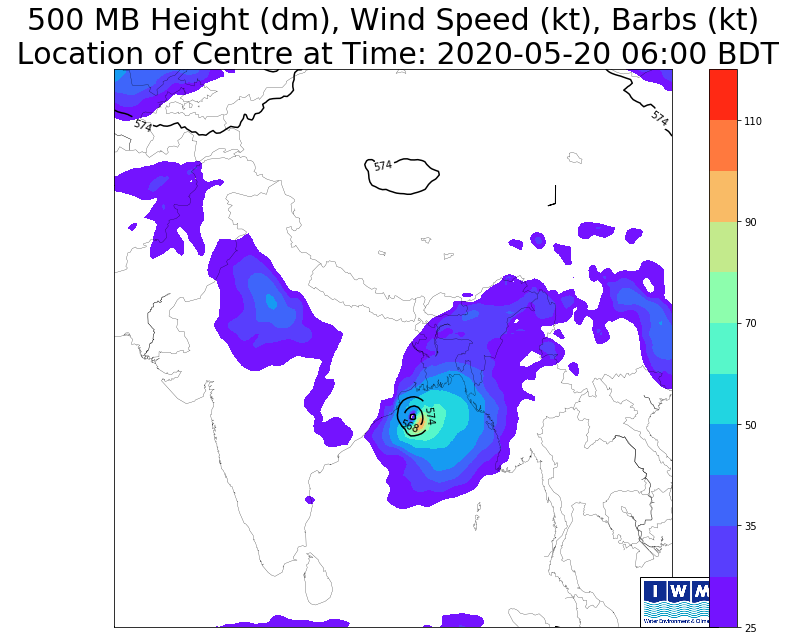

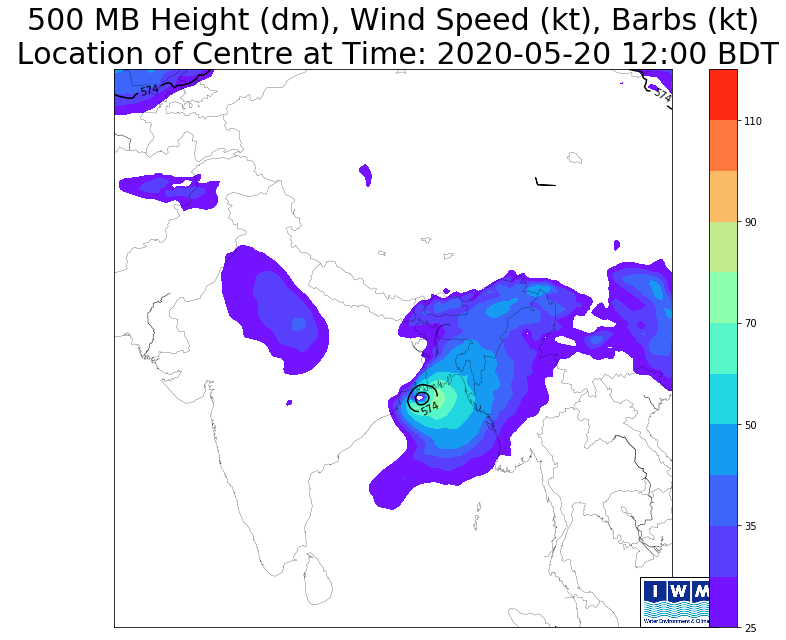

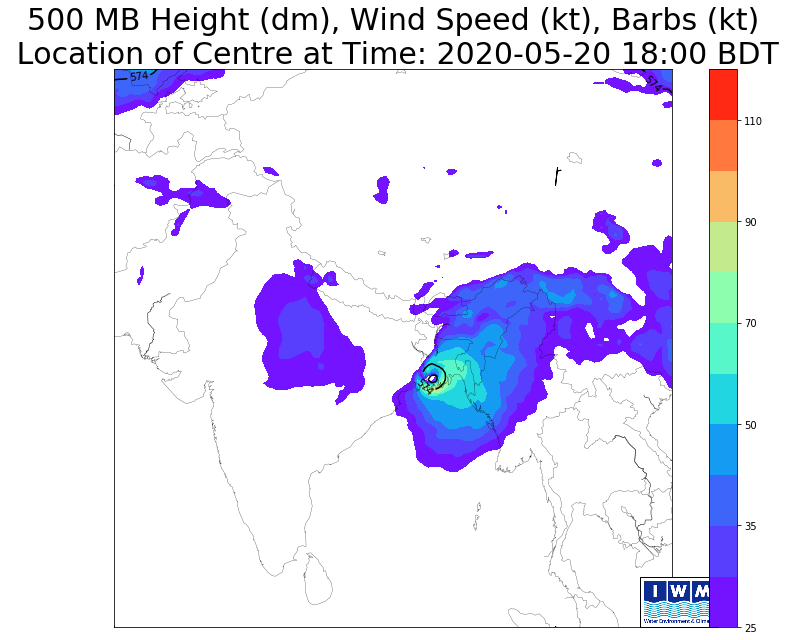

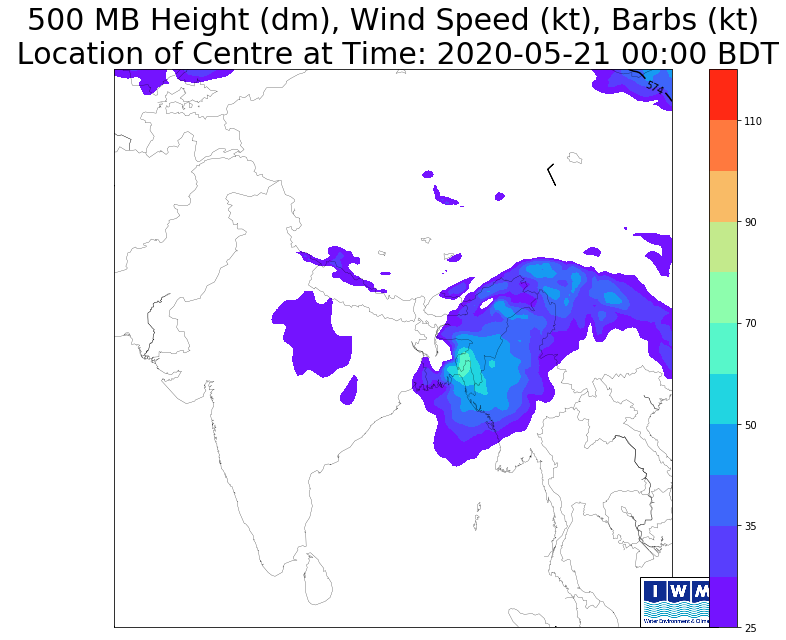

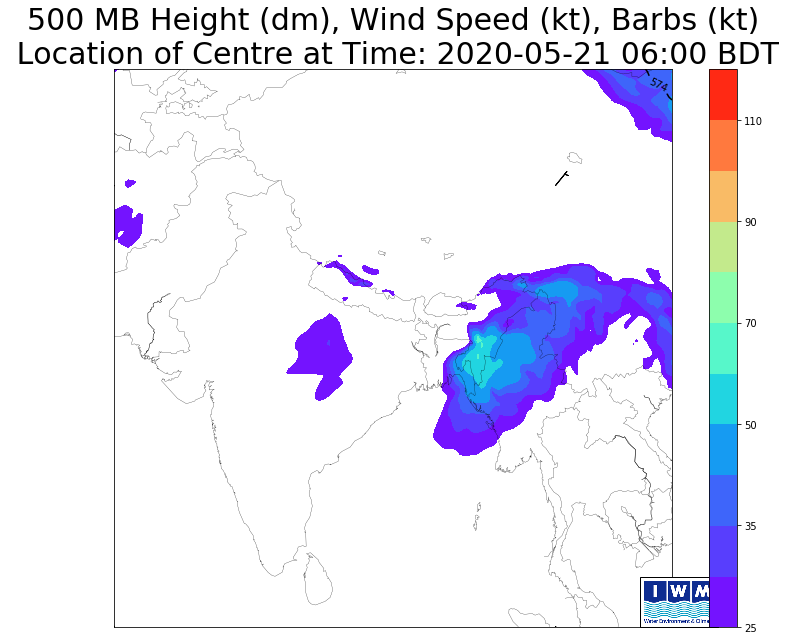

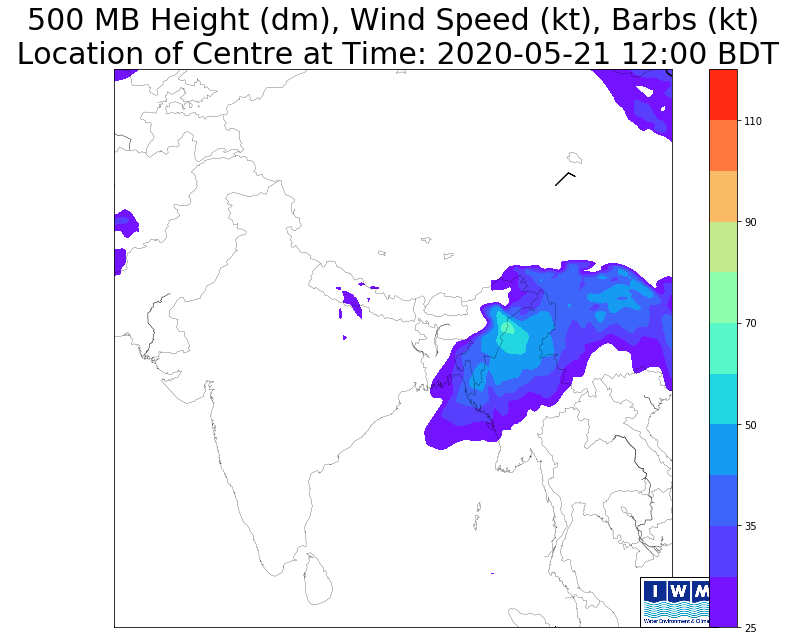

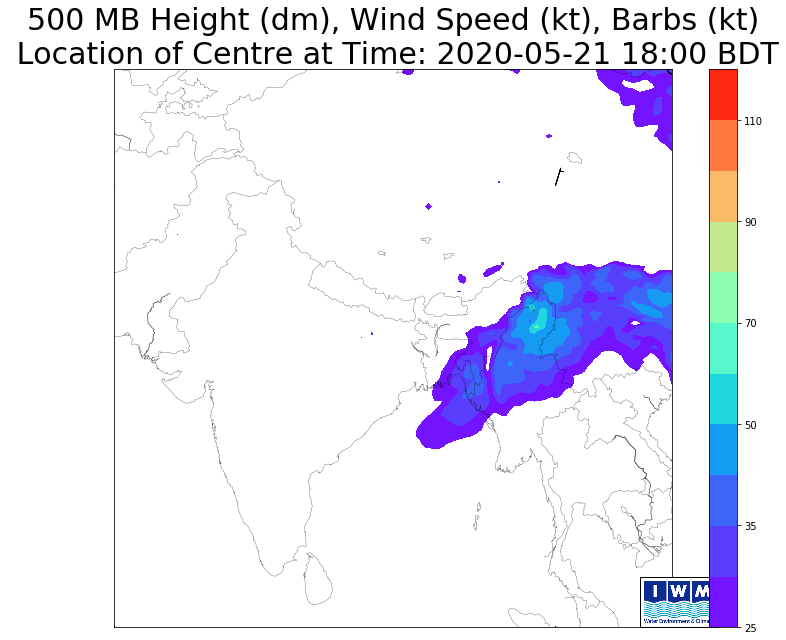

In [8]:
forecastDate = datetime(2020, 5, 18, 18)
#forecastDate = forecastDate+timedelta(hours=6)
for sht in range(0,12):
    arr_hand = read_png('IWM.png')
    imagebox = OffsetImage(arr_hand, zoom=.5)
    xy = [.5, .5]
    ab = AnnotationBbox(imagebox, xy,
        xybox=(565., 25.),
        xycoords='data',
        boxcoords="offset points")  
    #timeshifts = sht*6
    forecastDate = forecastDate+timedelta(hours=6)
    p = getvar(ncfile, "pressure",timeidx=sht)
    z = getvar(ncfile, "z", units="dm",timeidx=sht)
    ua = getvar(ncfile, "ua", units="kt",timeidx=sht)
    va = getvar(ncfile, "va", units="kt",timeidx=sht)
    wspd = getvar(ncfile, "wspd_wdir", units="kts",timeidx=sht)[0,:]
    ht_500 = interplevel(z, p, 500)
    u_500 = interplevel(ua, p, 500)
    v_500 = interplevel(va, p, 500)
    wspd_500 = interplevel(wspd, p, 500)
    lats, lons = latlon_coords(ht_500)

    # Get the basemap object
    bm = get_basemap(ht_500)

    # Create the figure
    fig = plt.figure(figsize=(12,9))
    ax = plt.axes()
    ax.add_artist(ab)
    x, y = bm(to_np(lons), to_np(lats))
    levels = np.arange(520., 580., 6.)
    contours = bm.contour(x, y, to_np(ht_500), levels=levels, colors="black")
    plt.clabel(contours, inline=1, fontsize=10, fmt="%i")
    levels = [25, 30, 35, 40, 50, 60, 70, 80, 90, 100, 110, 120]
    wspd_contours = bm.contourf(x, y, to_np(wspd_500), levels=levels,
                                cmap=get_cmap("rainbow"))
    plt.colorbar(wspd_contours, ax=ax, orientation="vertical", pad=.05)
    bm.drawcoastlines(linewidth=0.25)
    bm.drawstates(linewidth=0.25)
    bm.drawcountries(linewidth=0.25)
    bm.barbs(x[::125,::125], y[::125,::125], to_np(u_500[::125, ::125]),
             to_np(v_500[::125, ::125]), length=6)

    plt.title("500 MB Height (dm), Wind Speed (kt), Barbs (kt)\n Location of Centre at Time: " + forecastDate.strftime('%Y-%m-%d %H:%M')+ " BDT", fontsize=30)
    
    plt.tight_layout()
    plt.savefig(f'{sht+1}-amphan.jpg', dpi=300)

In [50]:
forecastDate = datetime(2020, 5, 18)
forecastDate = forecastDate+timedelta(hours=6)

In [53]:

forecastDate.strftime('%Y-%m-%d %H:%M')

'2020-05-18 06:00'

In [37]:
p = getvar(ncfile, "P")

In [46]:
ua.shape

(32, 159, 159)

In [39]:
help(getvar)


Help on function getvar in module wrf.routines:

getvar(wrfin, varname, timeidx=0, method='cat', squeeze=True, cache=None, meta=True, **kwargs)
    Returns basic diagnostics from the WRF ARW model output.
    
    A table of all available diagnostics is below.
    
    .. include:: ../../_templates/product_table.txt
    
    Args:
        wrfin (:class:`netCDF4.Dataset`, :class:`Nio.NioFile`, or an             iterable): WRF-ARW NetCDF
            data as a :class:`netCDF4.Dataset`, :class:`Nio.NioFile`
            or an iterable sequence of the aforementioned types.
    
        varname (:obj:`str`) : The variable name.
    
        timeidx (:obj:`int` or :data:`wrf.ALL_TIMES`, optional): The
            desired time index. This value can be a positive integer,
            negative integer, or
            :data:`wrf.ALL_TIMES` (an alias for None) to return
            all times in the file or sequence. The default is 0.
    
        method (:obj:`str`, optional): The aggregation metho

In [70]:
#from PIL import Image
#plane = np.array(Image.open('IWM.png'))

